**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any, Callable, NamedTuple, Optional
from pathlib import Path
import warnings

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2pos
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram, model_sky
from bloodmoon.optim import optimize

import darksun as ds
from darksun.utils import savefig_to

**Mask and Data Specifics**

In [2]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str | None = None
#ANALYSIS_ID: str | None = "singleCAM_iros_upx2upy1"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = (
    True if DATASET == 'reconstructed'
    else False
)

**Analysis Methods**

In [3]:
class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float


def search_setup(
    camera: CodedMaskCamera,
    snr_threshold: int | float,
    vignetting: bool,
    psfy: bool,
) -> tuple[
    Callable[[NDArray, NDArray, Optional[int]], tuple[int, int] | bool],
    Callable[[tuple[int, int], NDArray, NDArray], Candidate],
    Callable[[Candidate, NDArray], NDArray],
]:
    """
    Setup for searching source candidates inside a sky image, optimise their parameters
    and subtract the resulting shadowgrams from starting detector image.
    """

    def find_candidate(
        sky: NDArray,
        snr: NDArray,
        batch: int = 1000,
    ) -> tuple[int, int] | bool:
        """
        Returns the position of a valid IROS candidate inside the sky image.
        """
        reservoir = np.array(
            [np.unravel_index(id_, sky.shape) for id_ in np.argsort(sky, axis=None)[-batch:]]
        )
        for pos in reservoir[::-1]:
            if (snr[*pos] > snr_threshold):
                return tuple(pos)
        return False

    def fit_candidate_params(
        candidate_pos: tuple[int, int],
        sky: NDArray,
        snr: NDArray,
    ) -> Candidate:
        """Performs the optimisation of the source candidate params."""
        try:
            shift_x, shift_y, fluence = optimize(
                camera=camera,
                sky=sky,
                arg_sky=candidate_pos,
                vignetting=vignetting,
                psfy=psfy,
            )
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {str(e)}") from e
        
        significance = float(snr[*candidate_pos])
        return Candidate(shift_x, shift_y, fluence, significance)

    def subtract(
        candidate: Candidate,
        detector: NDArray,
    ) -> NDArray:
        """Subtracts candidate from detector image."""
        sg_model = model_shadowgram(
            camera=camera,
            shift_x=candidate.shift_x,
            shift_y=candidate.shift_y,
            vignetting=vignetting,
            psfy=psfy,
        )
        residual = detector - candidate.fluence * sg_model
        return residual
    
    return find_candidate, fit_candidate_params, subtract


def debug(
    detector: NDArray,
    camera: CodedMaskCamera,
    snr_threshold: int | float = 5.0,
    vignetting: bool = True,
    psfy: bool = True,
    varmap: NDArray | None = None,
) -> tuple[Candidate | None, NDArray]:
    """
    Debug IROS loop with:
        * candidate detection and params fit on sky image domain;
        * candidate subtraction on detector image domain.
    """
    find_candidate, fit_candidate_params, subtract = search_setup(
        camera, snr_threshold, vignetting, psfy,
    )

    detector_ = detector.copy()
    skymap = decode(camera, detector)
    varmap = (
        varmap if varmap is not None
        else variance(camera, detector)
    )
    snrmap = snratio(skymap, varmap)
    candidate_pos = find_candidate(skymap, snrmap)

    if not candidate_pos:
        print("\nNo candidates left...")
        return (None, detector_)

    try:
        source = fit_candidate_params(candidate_pos, skymap, snrmap)
    except RuntimeError as e:
        warnings.warn(f"Optimisation failed:\n\n{e}")
        return (None, detector_)

    detector_ = subtract(source, detector_)
    return (source, detector_)

In [4]:
def pixel_angular_resolution(
    camera: CodedMaskCamera,
) -> None:
    """Returns the camera pixels angular resolution."""
    pxdim_y, pxdim_x = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    dtheta_y, dtheta_x = map(
        lambda x: np.rad2deg(np.arctan(x / camera.specs.mask_detector_distance)) * 60,
        (pxdim_y, pxdim_x),
    )
    print(
        f"Pixel angular resolution at upscaling (x, y): {camera.upscale_f.x}, {camera.upscale_f.y}\n"
        f"  - fine direction: {dtheta_x:.4f} arcmin\n"
        f"  - coarse direction: {dtheta_y:.4f} arcmin"
    )
    return None


def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)

**Load Mask and Data**

In [5]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
ASPECT: float = (wfm.specs.mask_deltay / UPS_Y) / (wfm.specs.mask_deltax / UPS_X)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [6]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = (
    ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
    if ANALYSIS_ID is not None
    else (None, None)
)
#res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

**Analysis for LEM-X Camera A**

In [7]:
pixel_angular_resolution(wfm)

Pixel angular resolution at upscaling (x, y): 5, 1
  - fine direction: 0.8465 arcmin
  - coarse direction: 8.4653 arcmin


In [8]:
# init observed detector image data and variance
detector = count(wfm, sdlA.DLdata)[0]
true_sky = decode(wfm, detector)
varmap = variance(wfm, detector)

## USING BULK MASK with 1.5 mm cover ##


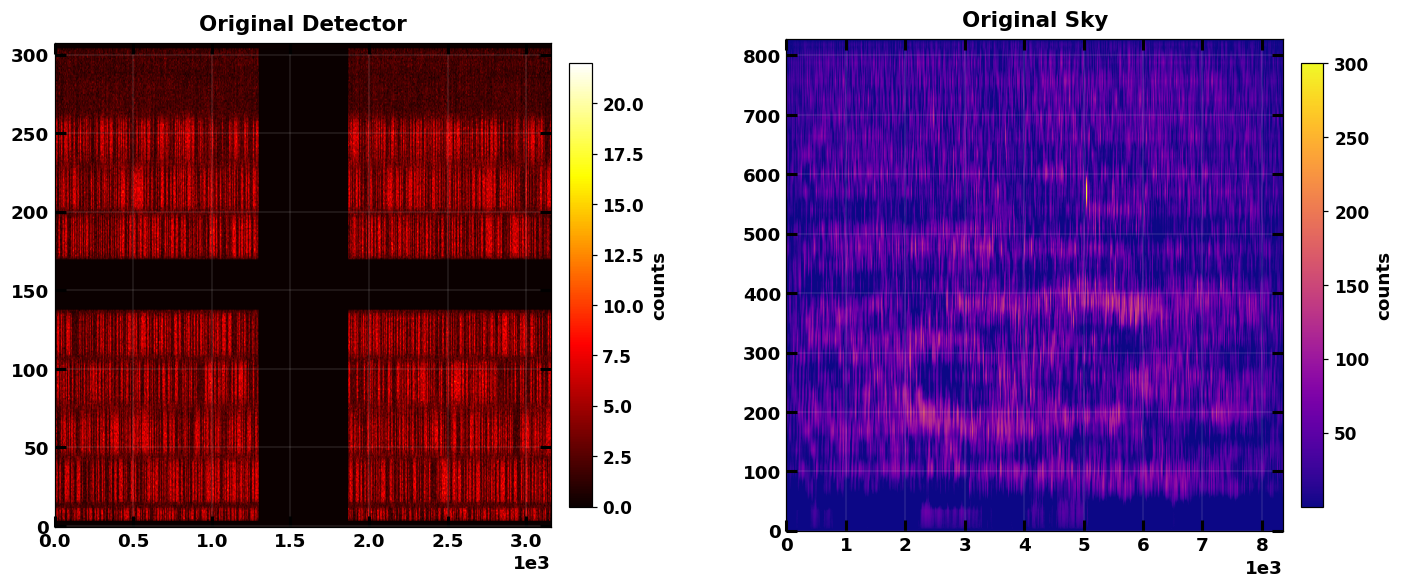

In [9]:
EXP = 0.5
sky_vmax = 3e2

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title='Original Detector',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': 0, #np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(true_sky, EXP),
            title='Original Sky',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

In [10]:
# 1st source subtraction
cand_first, res_det_first = debug(
    detector=detector,
    camera=wfm,
    snr_threshold=5.0,
    vignetting=VIGNETTING,
    psfy=PSFY,
    varmap=varmap,
)
res_sky_first = decode(wfm, res_det_first)

cand_first


## Optimisation Results:
  - fluence START: 977998.2566992759
  - shifts START (x, y): 43.89999999999998, 78.0
  - fluence OPTIM.: 1060670.396167939
  - shifts OPTIM. (x, y): 43.90951606519697, 78.04480373383348
  - fluence GAIN %: 8.453
  - shift_x GAIN %: 0.022
  - shift_y GAIN %: 0.057



Candidate(shift_x=43.90951606519697, shift_y=78.04480373383348, fluence=1060670.396167939, snr=728.3862024243957)

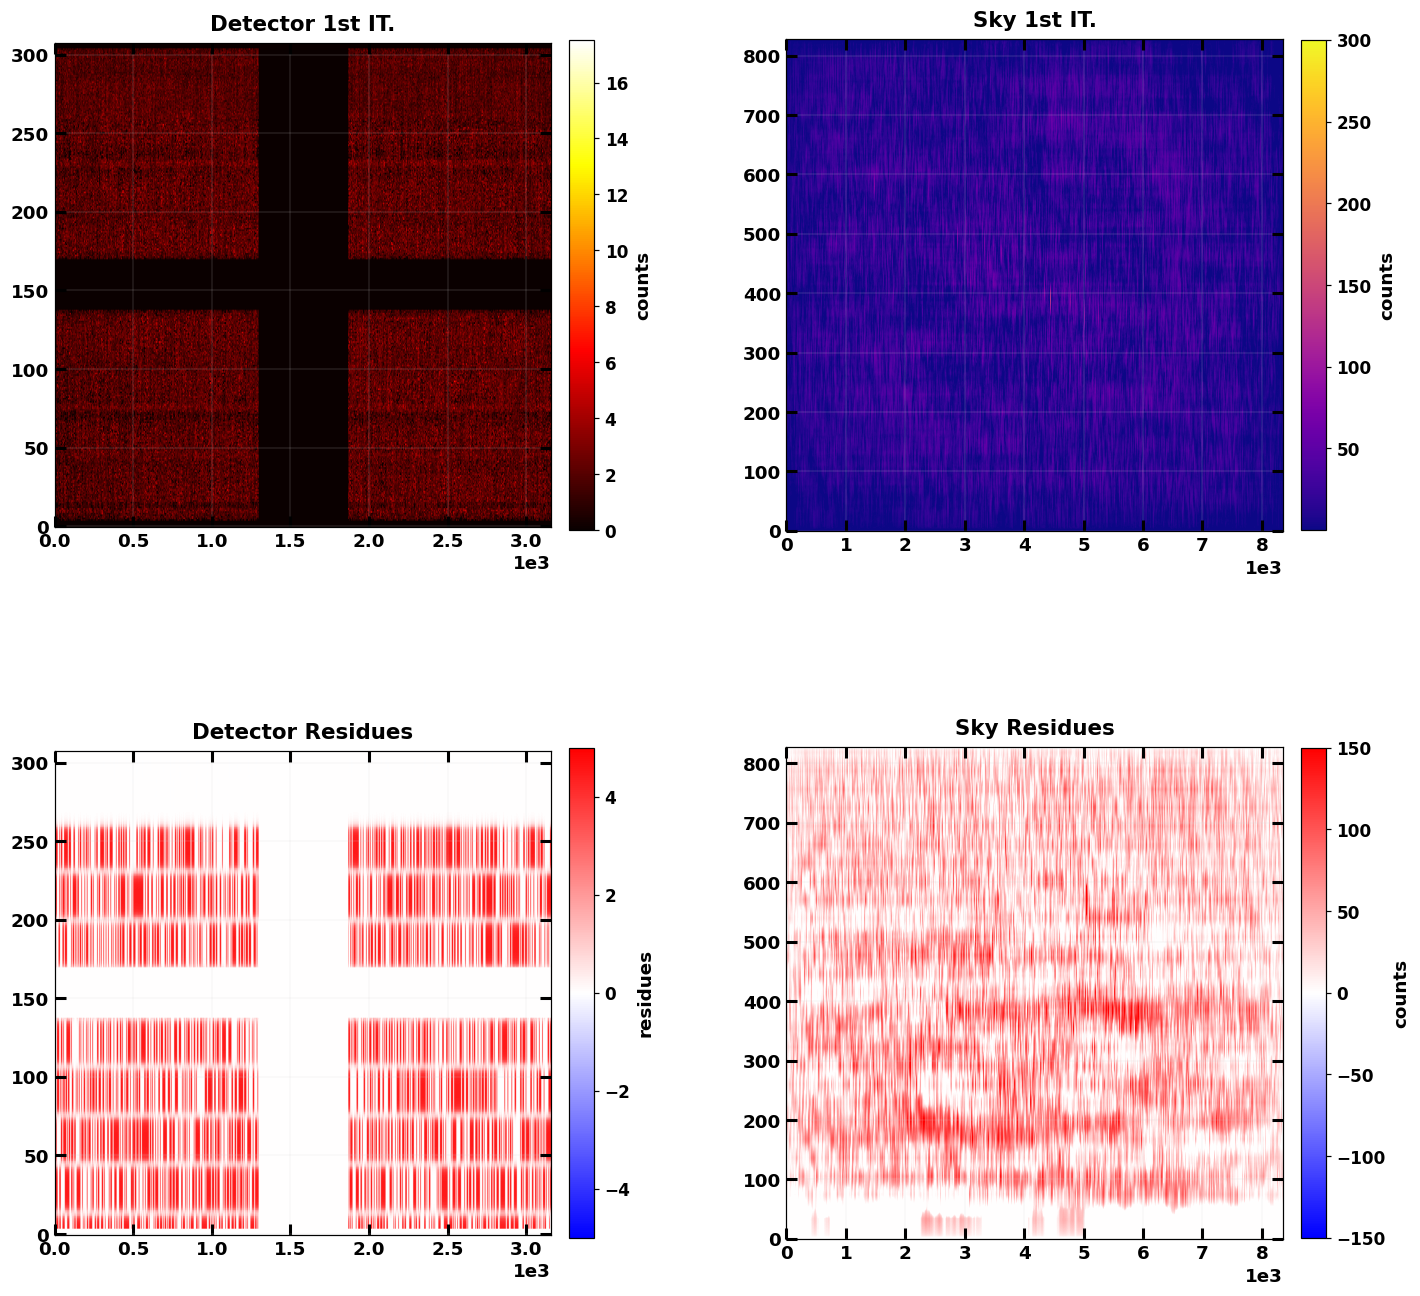

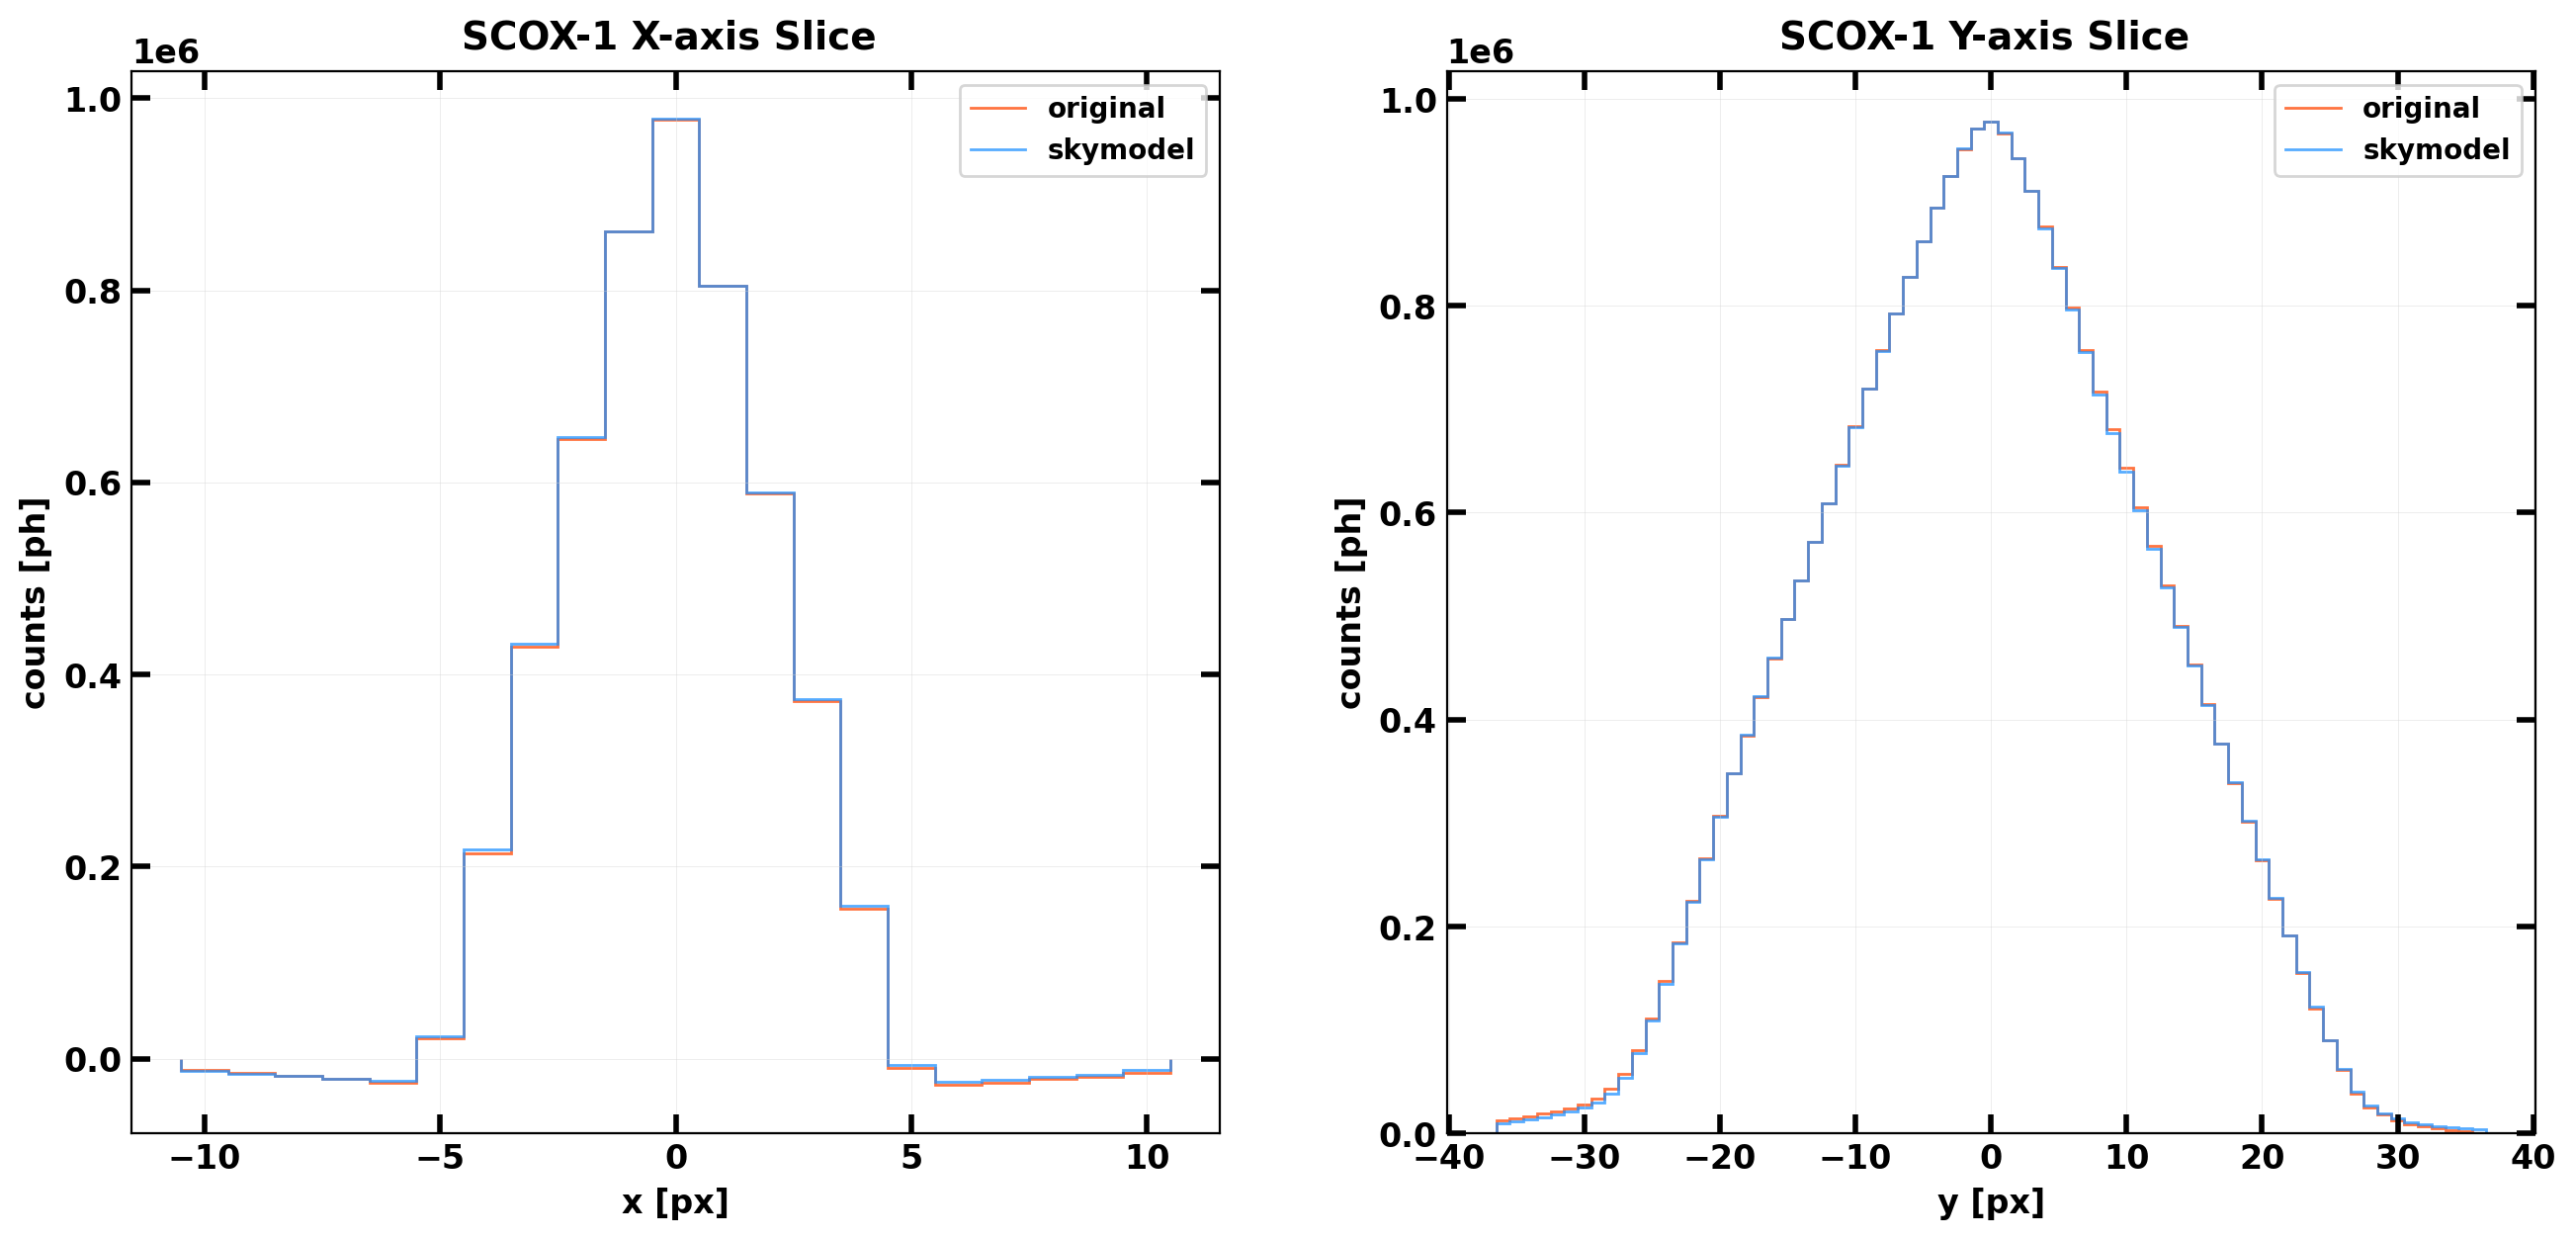

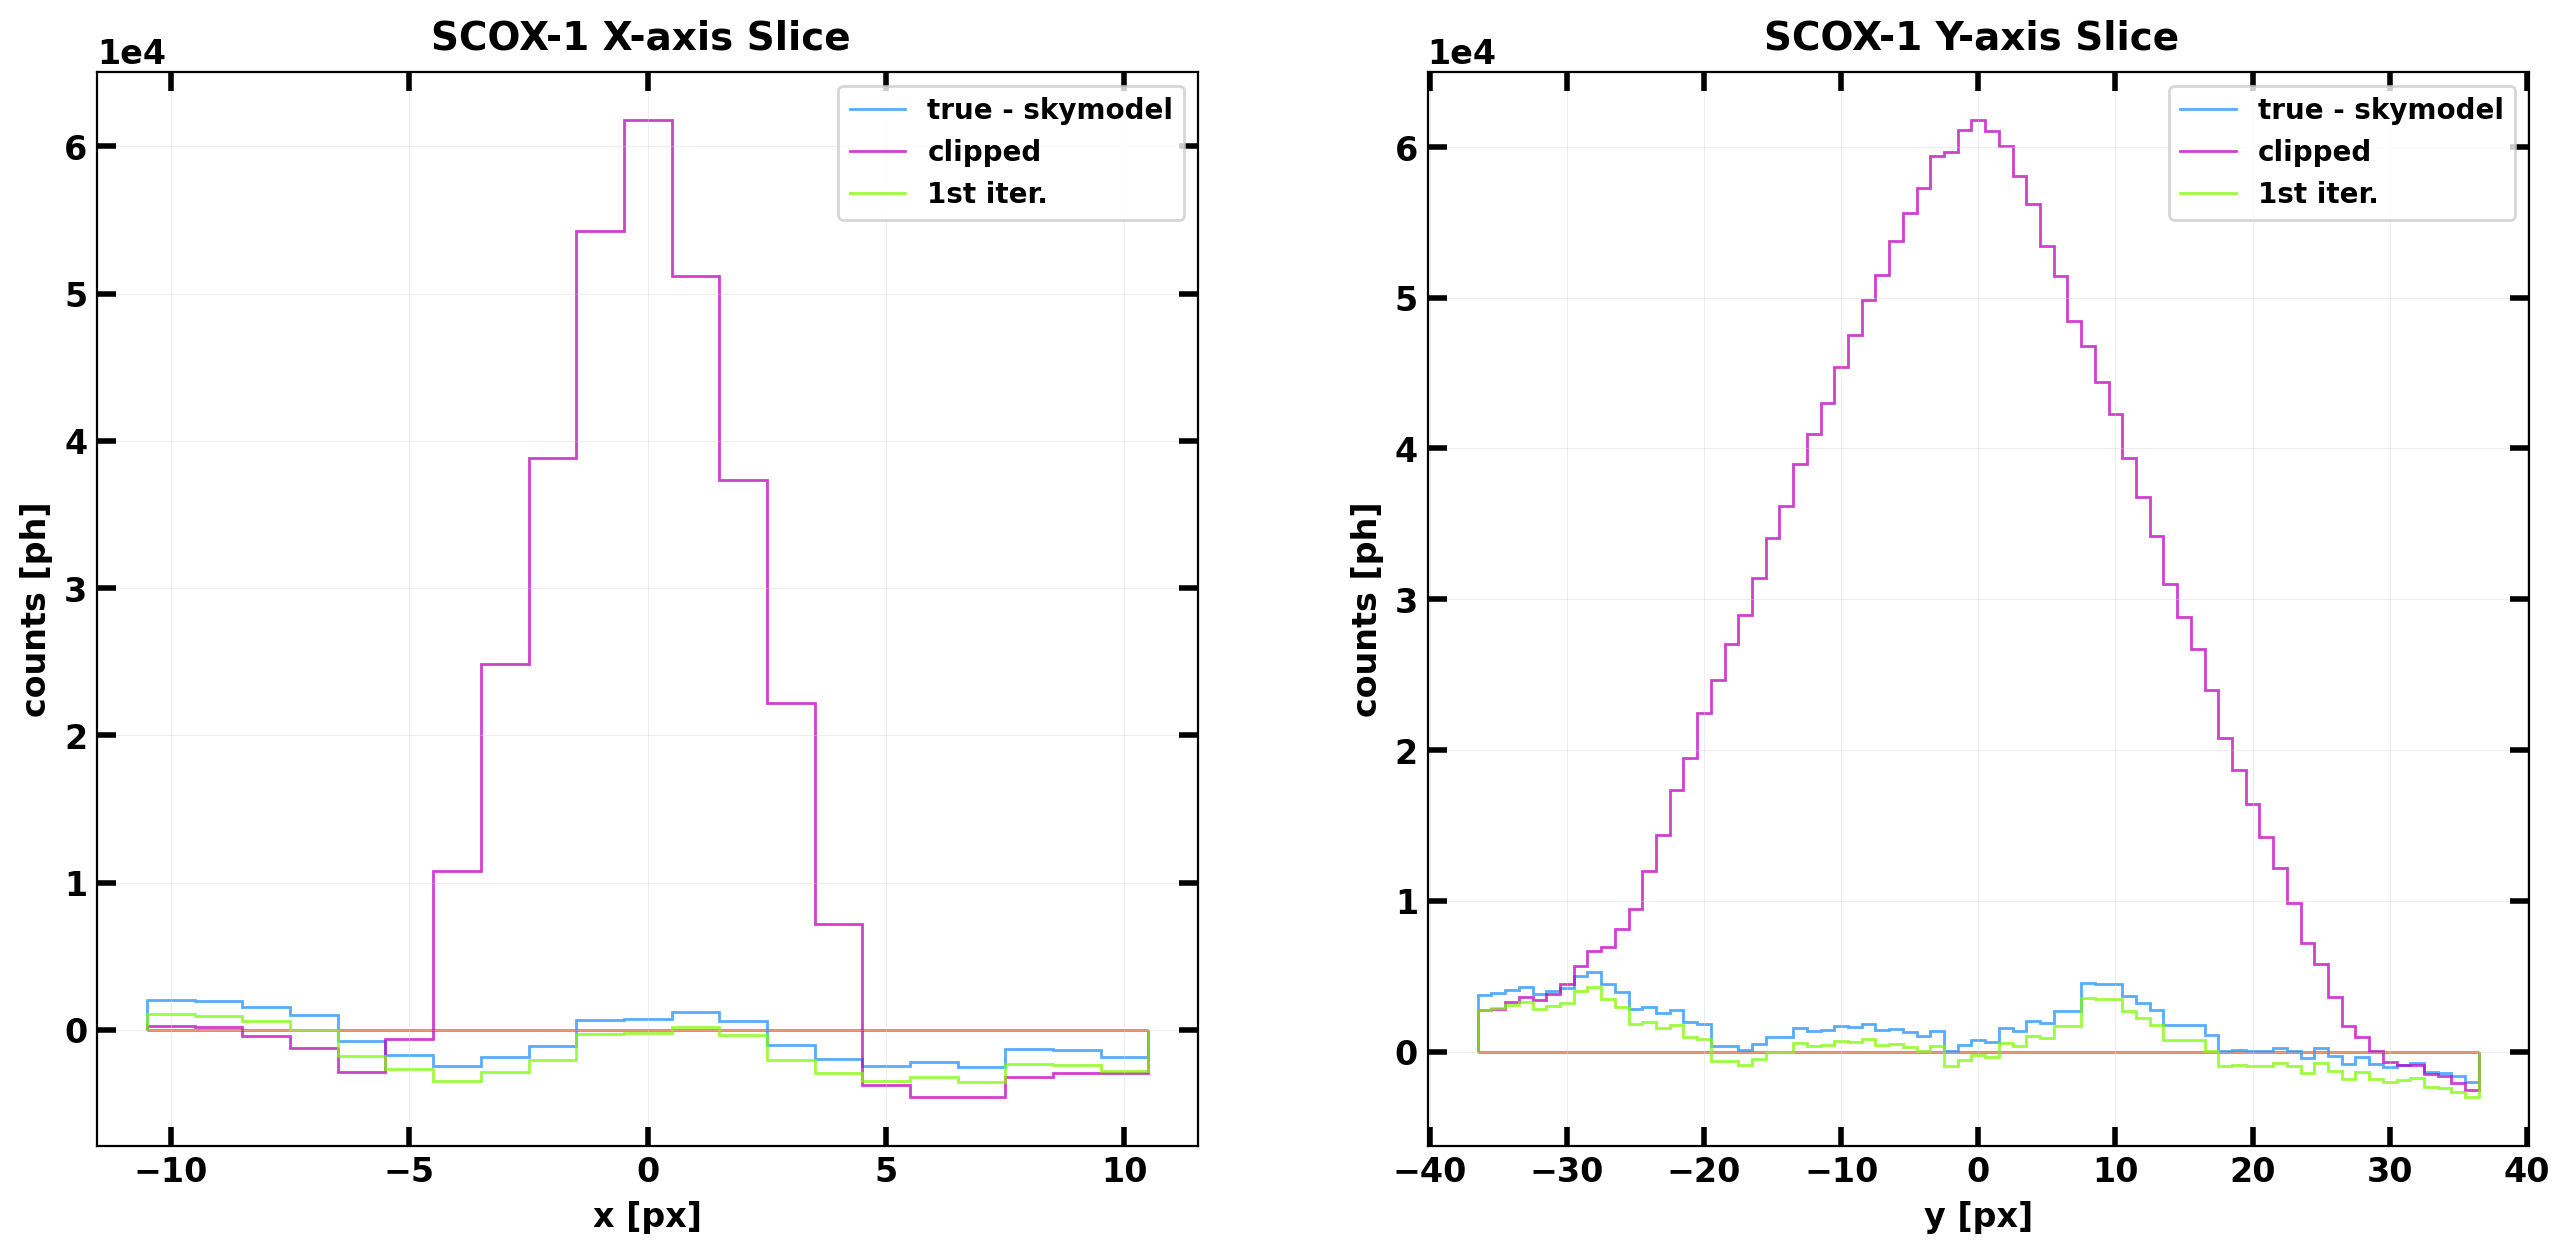

In [ ]:
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=res_det_first,
            title='Detector 1st IT.',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': 0, #np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_sky_first, EXP),
            title='Sky 1st IT.',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=detector - res_det_first,
            title='Detector Residues',
            cbarlabel='residues',
            img_kwargs={
                'cmap': 'bwr',
                'vmax': 5,
                'vmin': -5, #np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(true_sky - res_sky_first, EXP),
            title='Sky Residues',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'bwr',
                'vmax': 0.5 * sky_vmax,
                'vmin': -0.5 * sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
    nrows=2,
)

pos = shift2pos(wfm, cand_first.shift_x, cand_first.shift_y)
crp = (
    int(wfm.specs.slit_deltay * UPS_Y / wfm.specs.mask_deltay + 5),
    int(wfm.specs.slit_deltax * UPS_X / wfm.specs.mask_deltax + 5),
)


skymodel = model_sky(
    wfm, cand_first.shift_x, cand_first.shift_y, cand_first.fluence, VIGNETTING, PSFY,
)
ds.slices_plot(
    sky=(true_sky, skymodel),
    pos=pos,
    crp=crp,
    source='scox-1',
    labels=('original', 'skymodel'),
)

detmodel = model_shadowgram(wfm, cand_first.shift_x, cand_first.shift_y, VIGNETTING, PSFY) * cand_first.fluence
from_sg = decode(wfm, np.clip(detector - detmodel, a_min=0.0, a_max=None))
ds.slices_plot(
    sky=(np.zeros(wfm.shape_sky), true_sky - skymodel + 1e3, from_sg, res_sky_first),
    pos=pos,
    crp=crp,
    source='scox-1',
    labels=('', 'true - skymodel', 'clipped', '1st iter.'),
)

Selected 1103435 ph out of 2564475 ph.


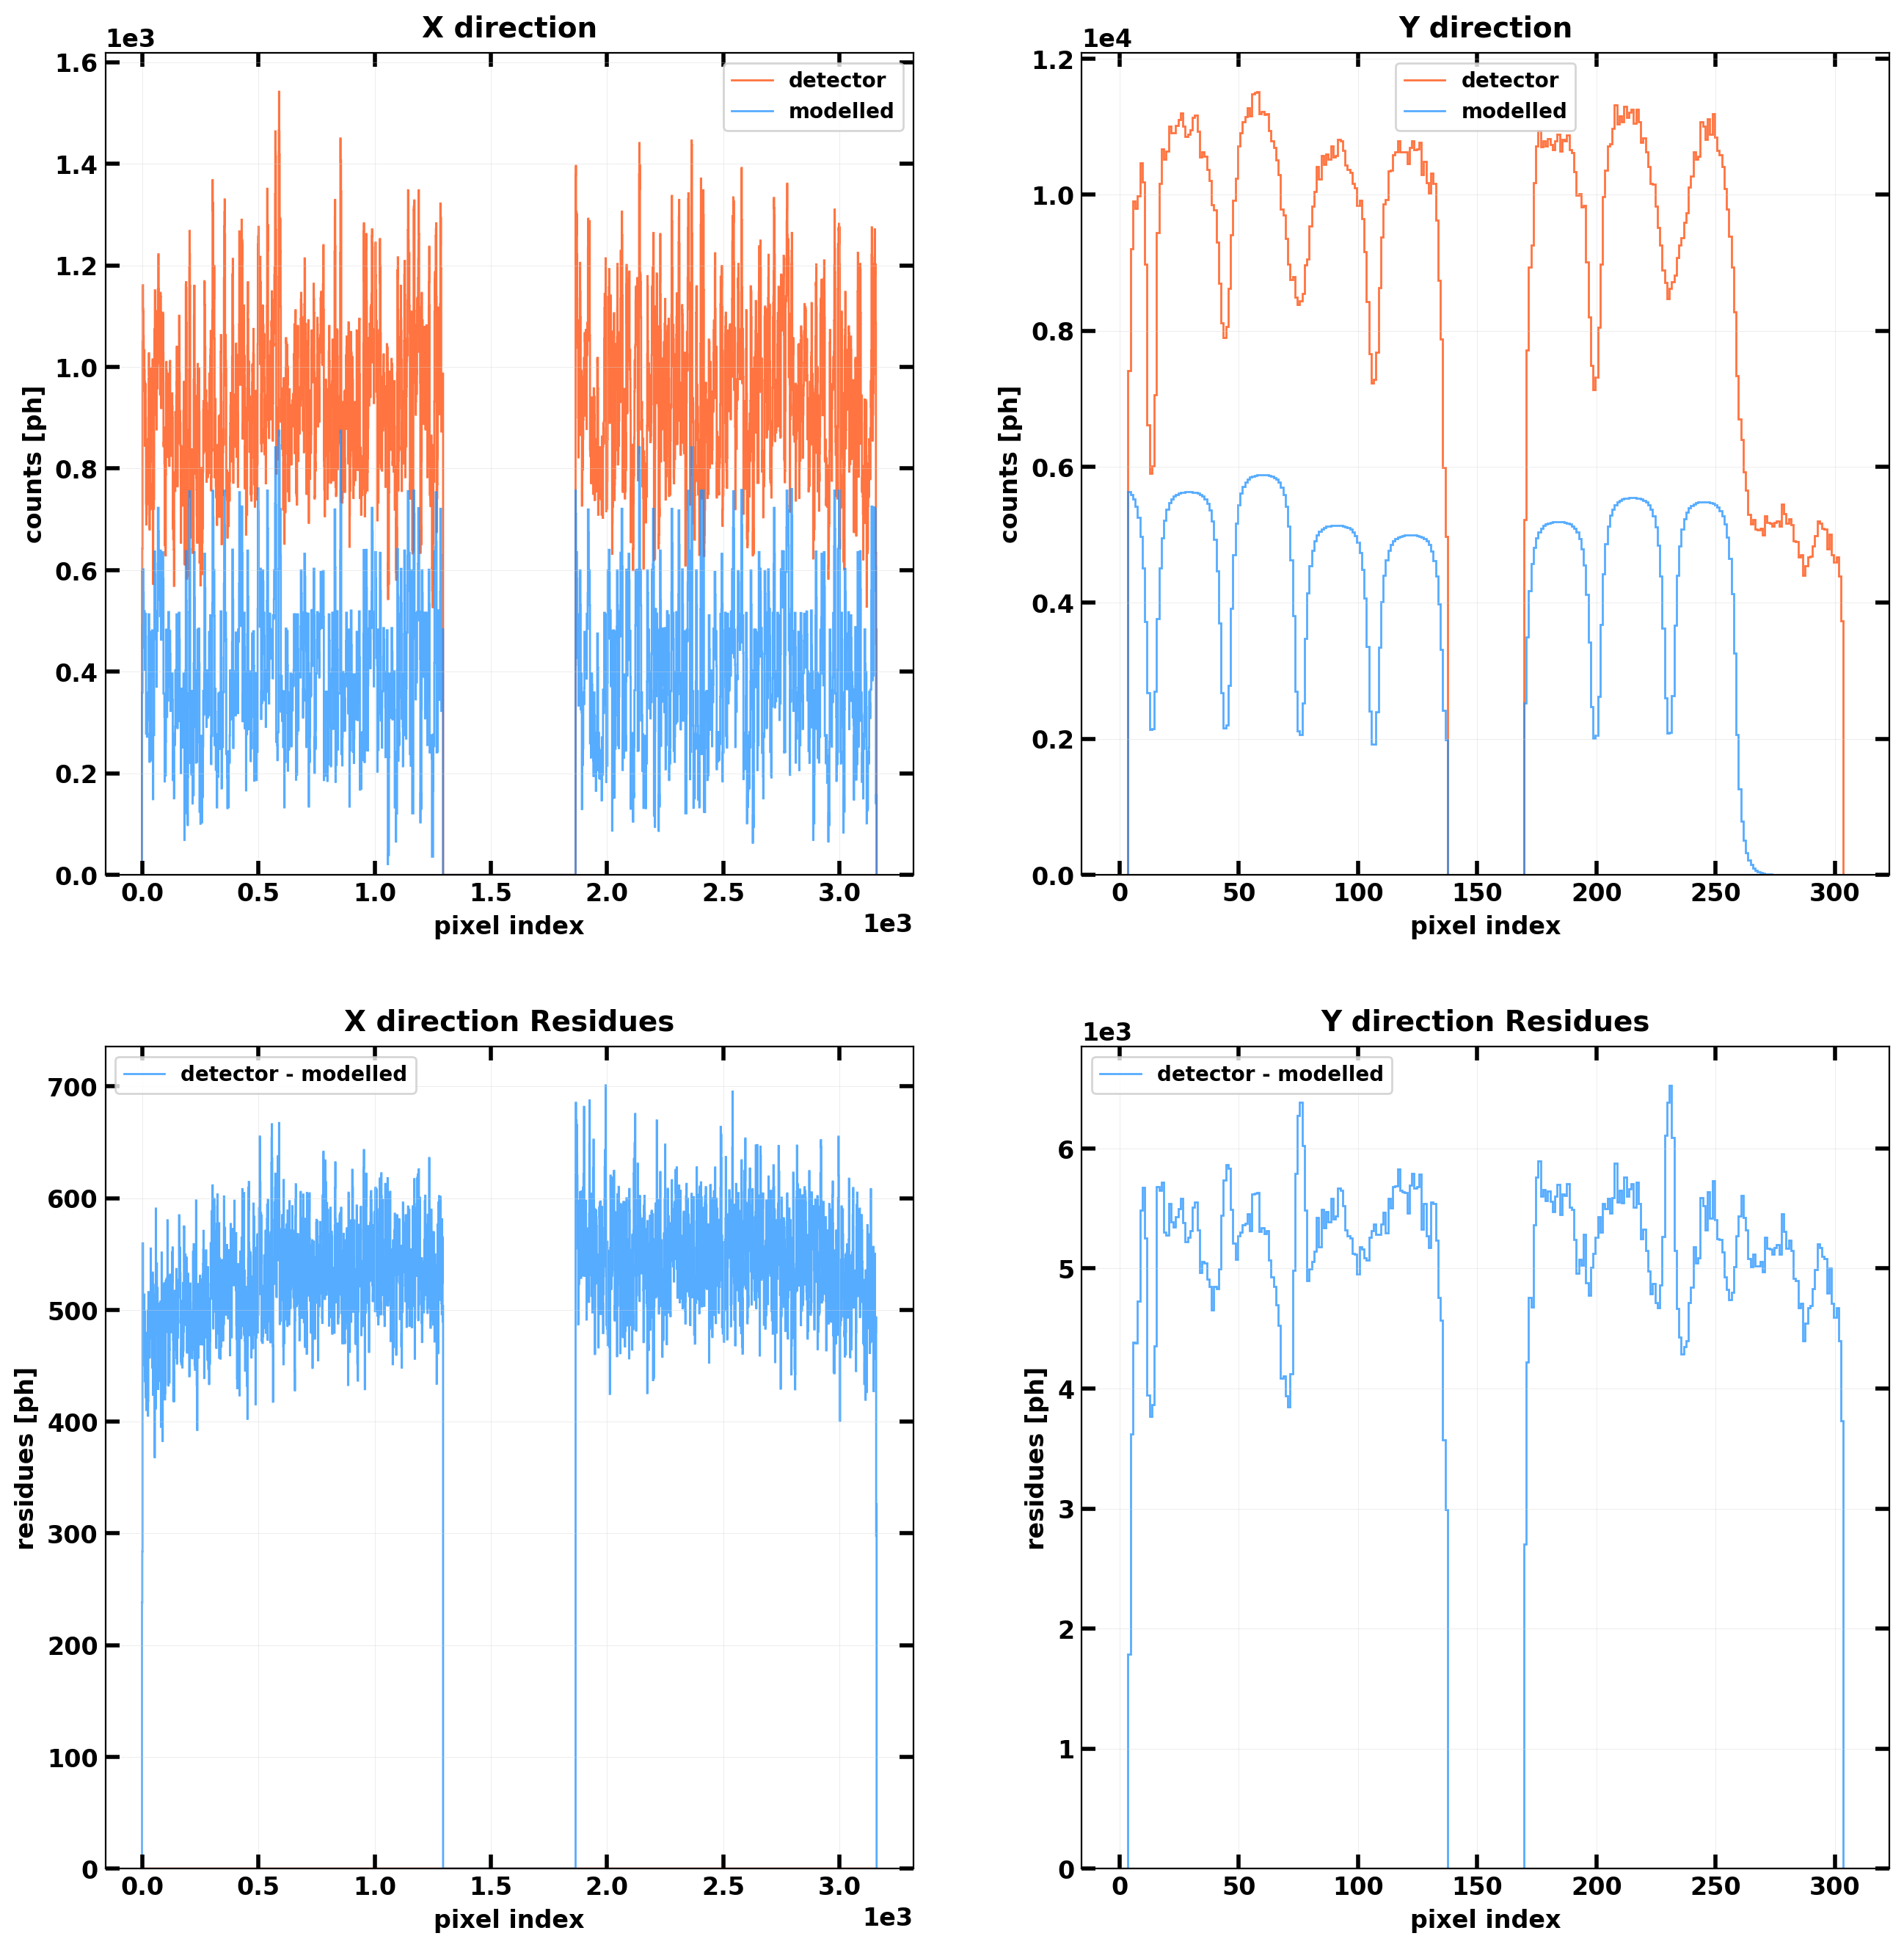

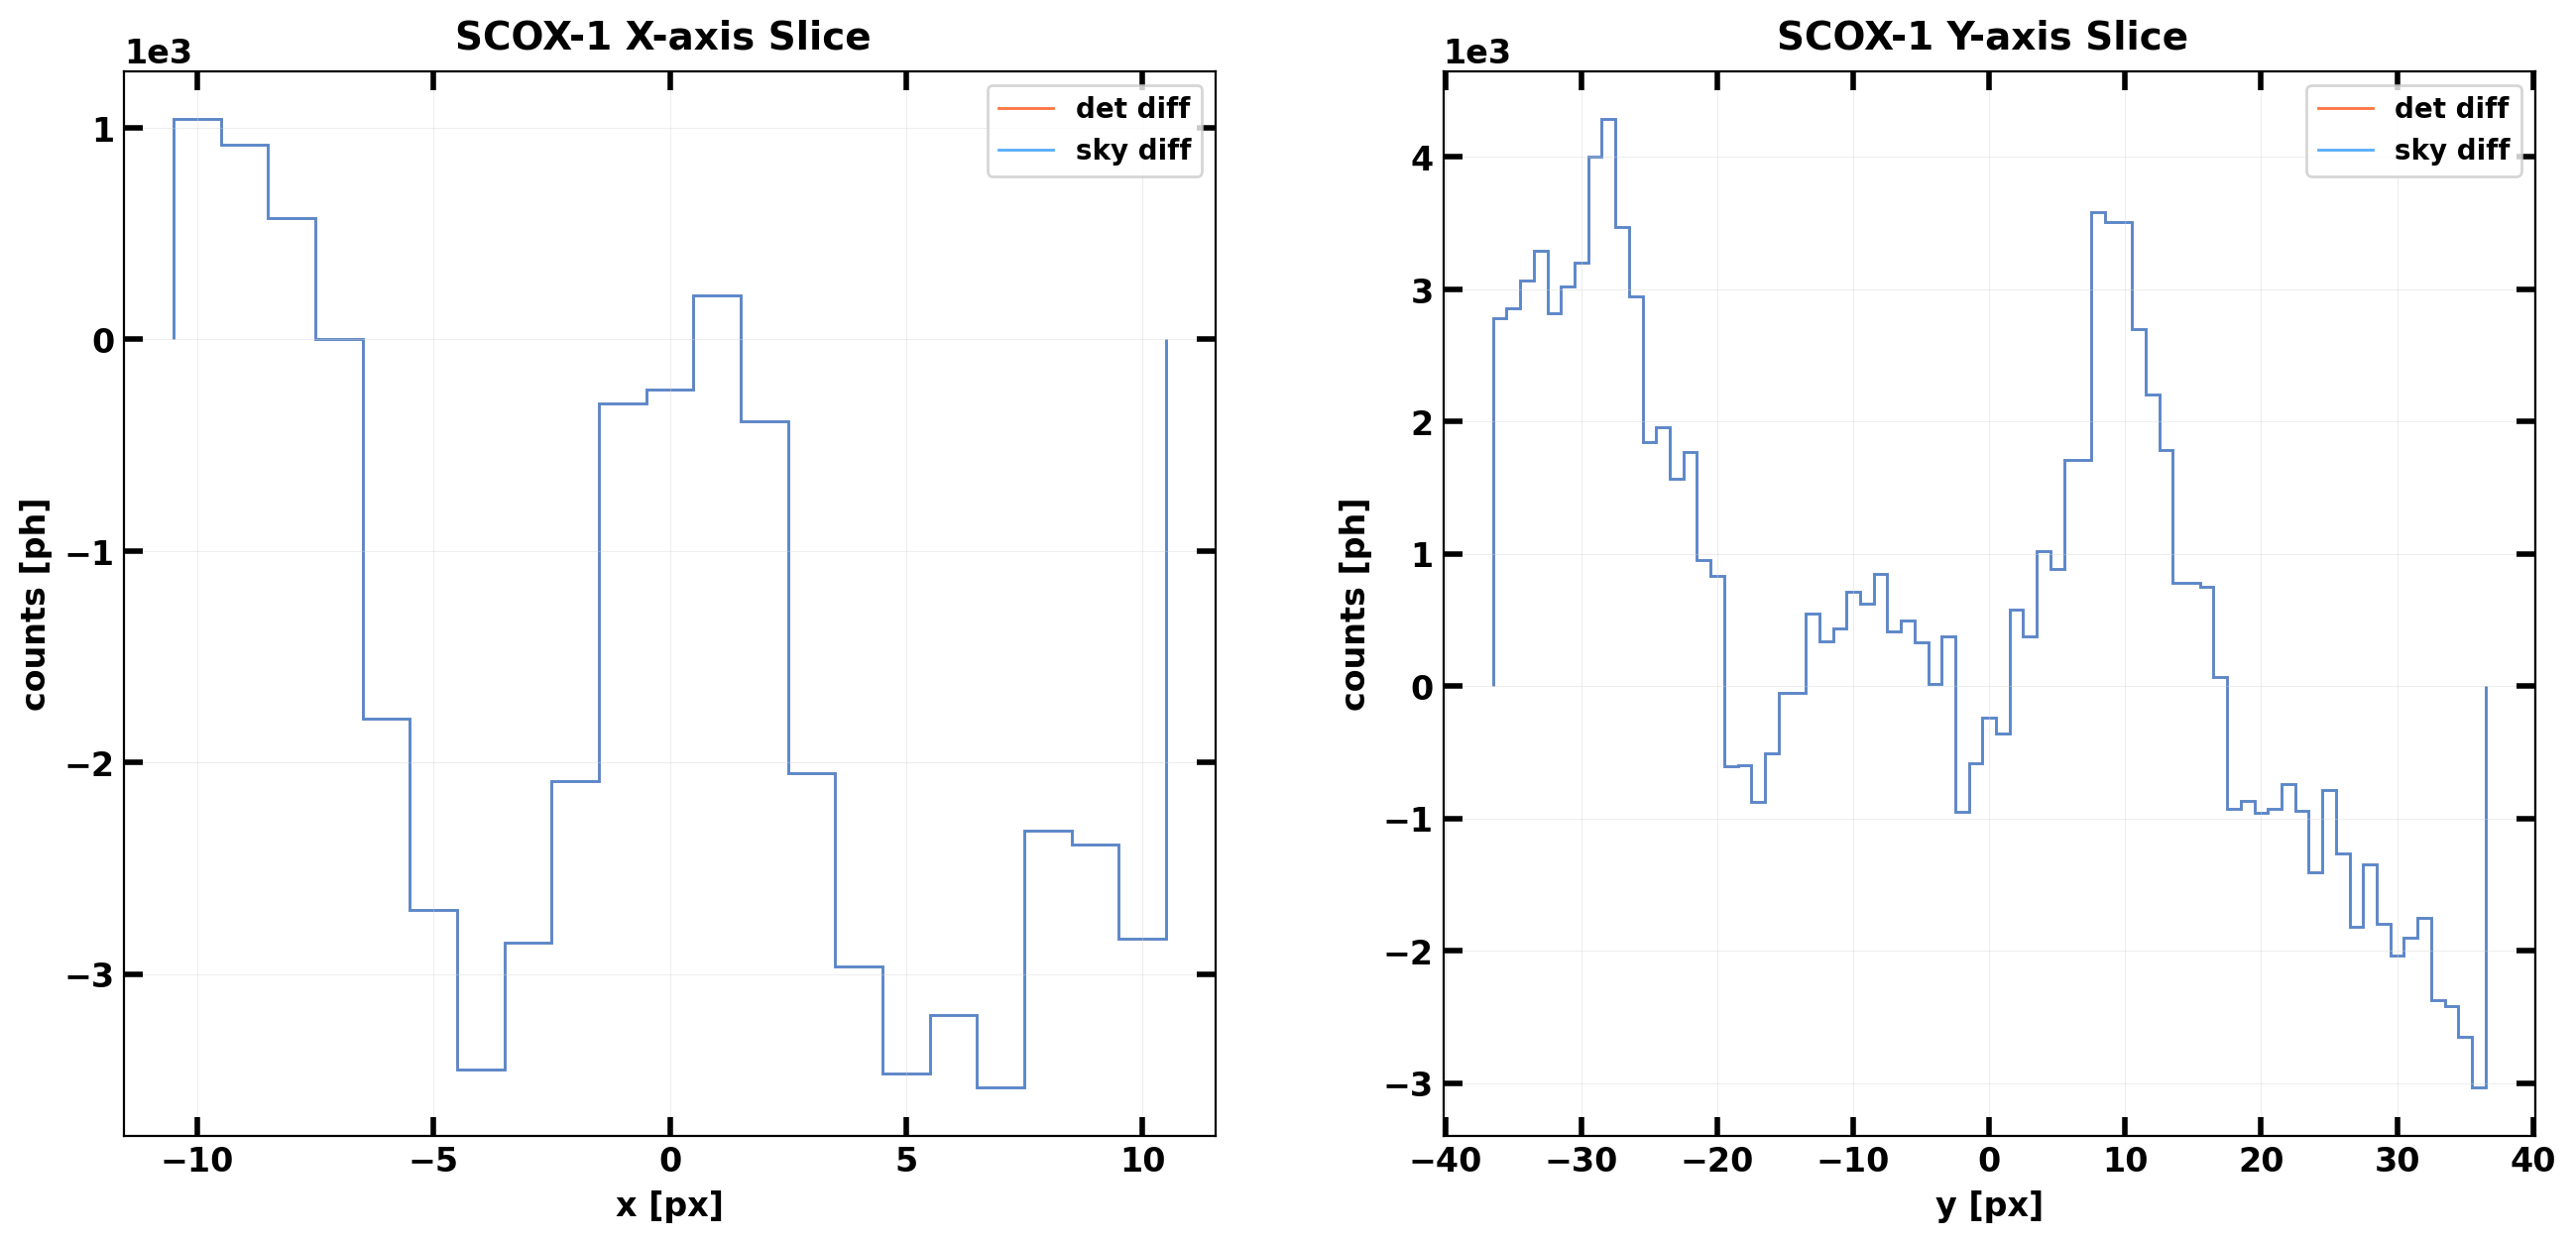

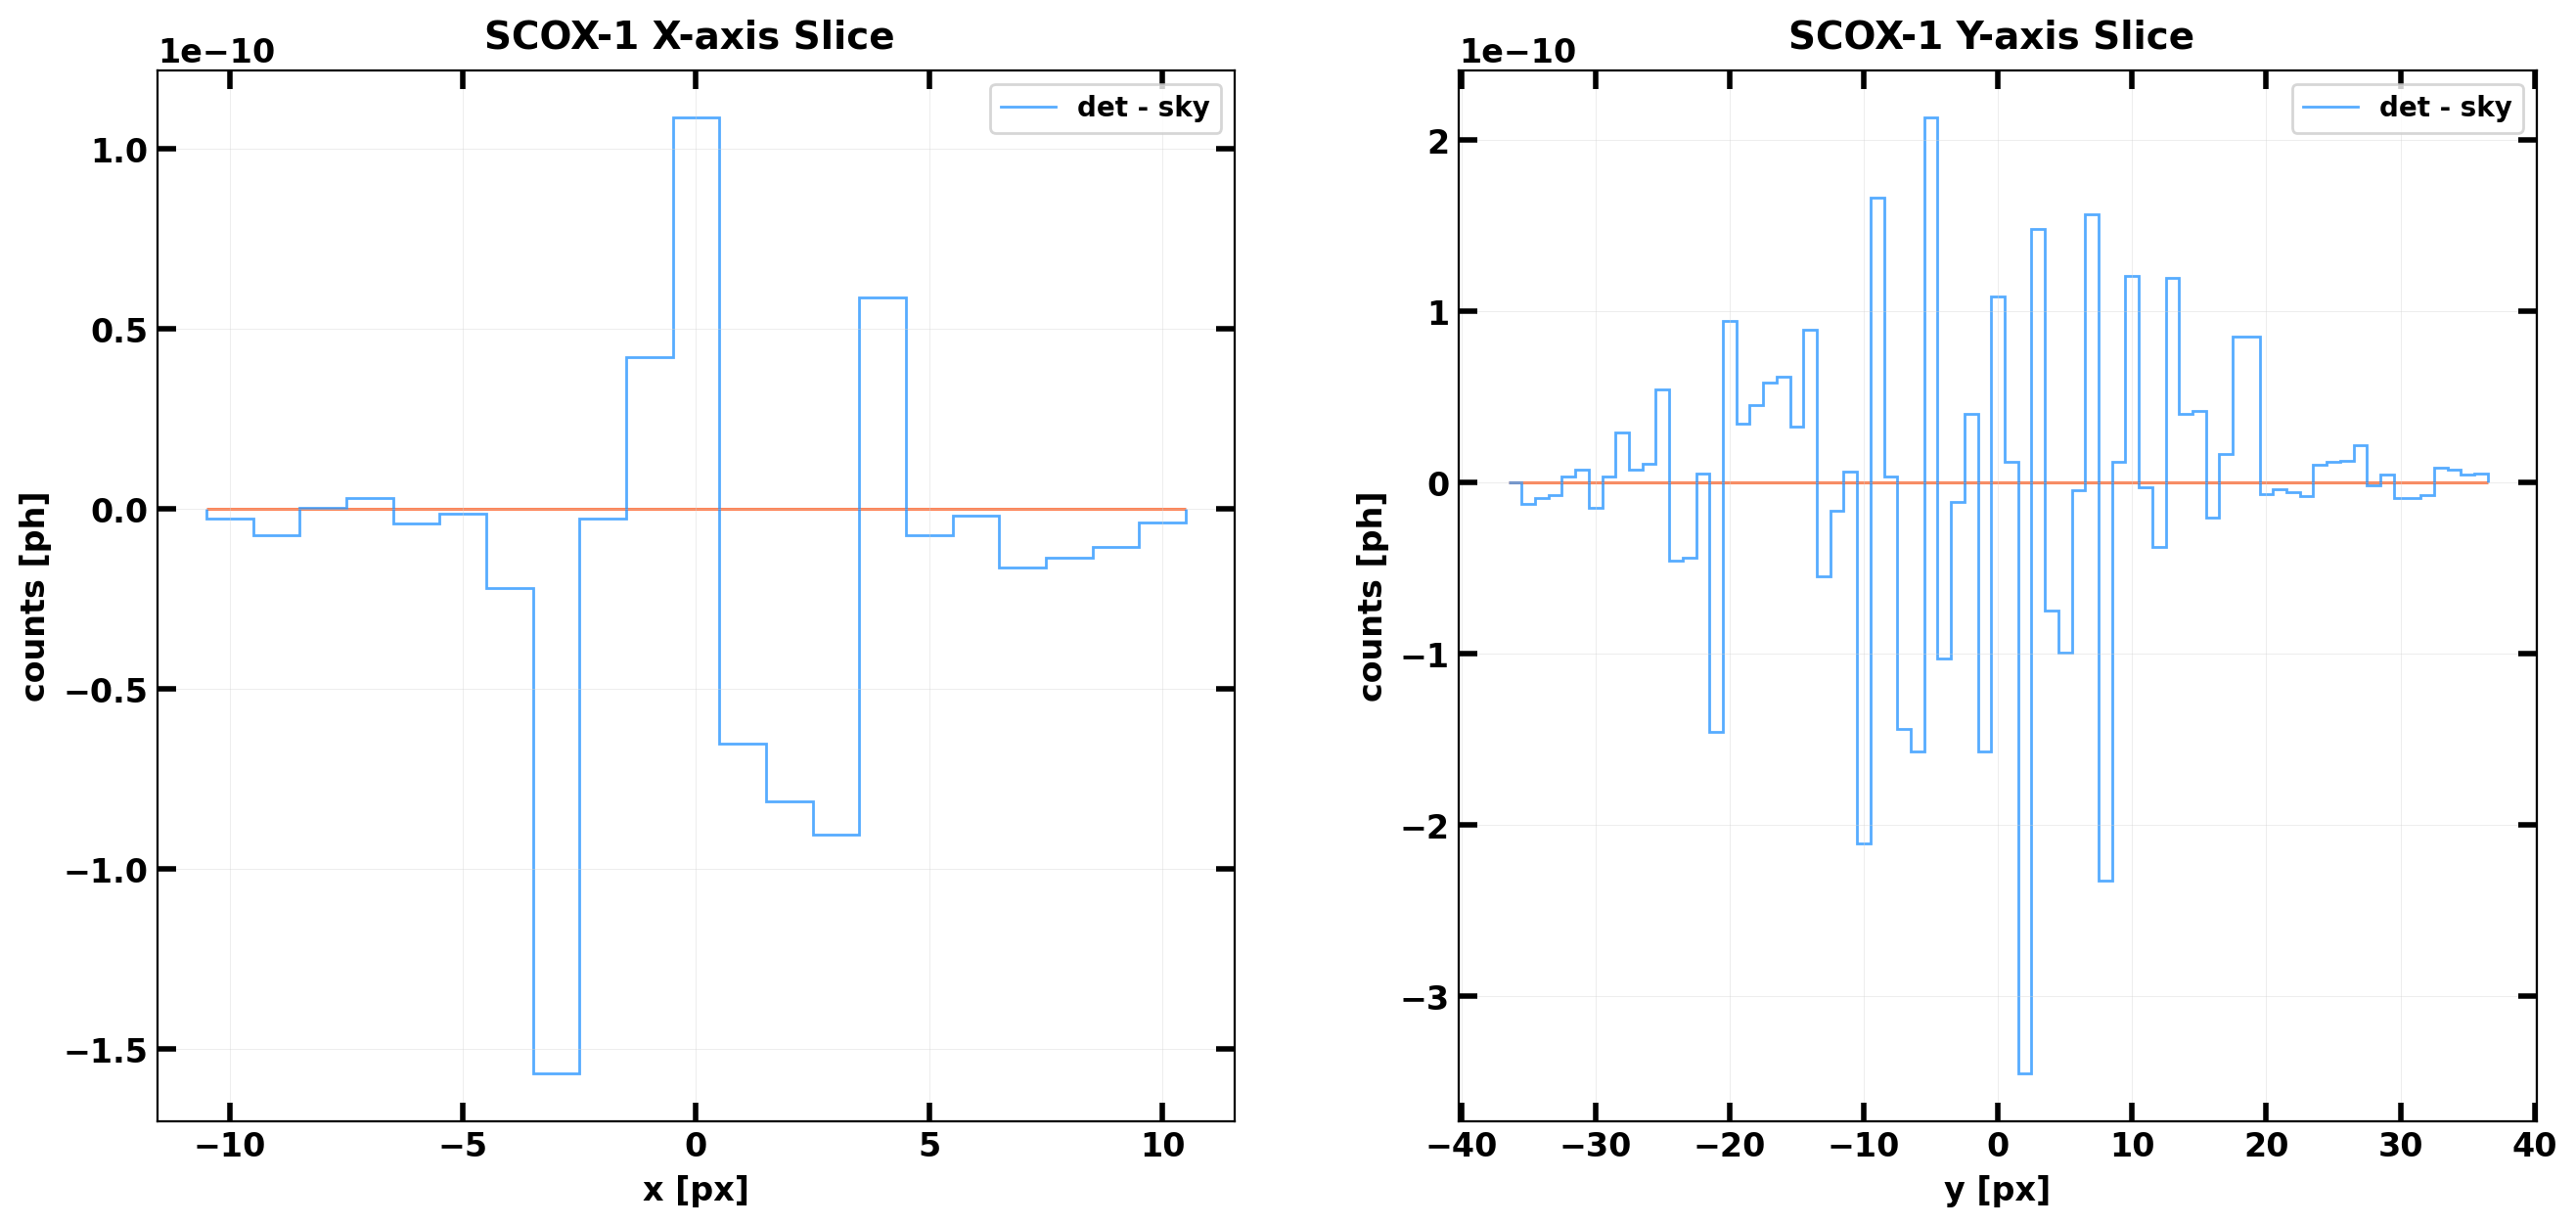

In [ ]:
from astropy.io.fits.fitsrec import FITS_rec
from bloodmoon.types import CoordEquatorial

def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """
    Collapses input 2D array by adding the elements along
    one axis, for both the (x, y) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the y axis
            - collapsed array along the x axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along y has length `m`, while the collapsed
          array along x has length `n`.
    """
    return np.sum(arr, axis=0), np.sum(arr, axis=1)


def select_source_photons(
    coords: CoordEquatorial | tuple[CoordEquatorial, ...],
    data: FITS_rec,
) -> FITS_rec:
    """
    Selects photon events relative to the input source RA/Dec coords.
    """
    mask = np.ones(len(data), dtype=bool)
    for c in ((coords,) if isinstance(coords, CoordEquatorial) else coords):
        mask &= (
            (np.isclose(data['RA'], c.ra) & np.isclose(data['DEC'], c.dec))
        )
    selected = data[mask]
    print(f'Selected {len(selected)} ph out of {len(data)} ph.')
    return selected


source_ID = 'scox1'


source_rec = catalogueA.DLdata[(catalogueA.DLdata['ID'] == source_ID)]
coords = CoordEquatorial(source_rec['RA'][0], source_rec['DEC'][0])
source_photons = select_source_photons(coords=coords, data=sdlA.DLdata)

det_scox1 = detector.copy()
#det_scox1 = count(wfm, source_photons)[0]
sky_scox1 = decode(wfm, det_scox1)

sg_scox1 = model_shadowgram(wfm, cand_first.shift_x, cand_first.shift_y, VIGNETTING, PSFY) * cand_first.fluence #(cand_first.fluence - 8.8e4)
modelled_scox1 = decode(wfm, sg_scox1)


det_collps_x, det_collps_y = collapse_view(det_scox1)
scox1_collps_x, scox1_collps_y = collapse_view(sg_scox1)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_collps_x, scox1_collps_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_collps_x, scox1_collps_x)
    ),
    color=('OrangeRed', 'DodgerBlue'),
    style='stairs',
)
dmap_res_collapsed_x = ds.map4plot(
    arrs=(np.zeros(len(det_collps_x)), det_collps_x - scox1_collps_x),
    title='X direction Residues',
    ylabel='residues [ph]',
    xlabel='pixel index',
    labels=('', 'detector - modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (np.zeros(len(det_collps_x)), det_collps_x - scox1_collps_x,)
    ),
    color=('OrangeRed', 'DodgerBlue'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_collps_y, scox1_collps_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_collps_y, scox1_collps_y)
    ),
    color=('OrangeRed', 'DodgerBlue'),
    style='stairs',
)
dmap_res_collapsed_y = ds.map4plot(
    arrs=(np.zeros(len(det_collps_y)), det_collps_y - scox1_collps_y),
    title='Y direction Residues',
    ylabel='residues [ph]',
    xlabel='pixel index',
    labels=('', 'detector - modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (np.zeros(len(det_collps_y)), det_collps_y - scox1_collps_y,)
    ),
    color=('OrangeRed', 'DodgerBlue'),
    style='stairs',
)
ds.plot(
    (
        dmap_collapsed_x, dmap_collapsed_y,
        dmap_res_collapsed_x, dmap_res_collapsed_y,
    ),
    ncols=2,
    nrows=2,
)

ds.slices_plot(
    sky=(np.zeros(wfm.shape_sky), decode(wfm, det_scox1 - sg_scox1)),
    pos=pos,
    crp=crp,
    source='scox-1',
    labels=('', 'diff'),
)

In [15]:
d_ = det_scox1 - sg_scox1

d_[(d_ < 0)].sum(), d_[(d_ > 0)].sum()

(np.float64(-69236.99101503794), np.float64(1456437.594847098))

In [16]:
# diff between sky imgs sub and decoding from subtracted detector img